# PubLayNet Document Layout Detection Benchmark Analysis

## Executive Summary

**Dataset:** PubLayNet - Document Layout Detection  
**Total Samples:** 500 images per phase  
**Task:** Bounding box extraction for document elements (text, title, list, table, figure)  
**Evaluation Metrics:** IoU (Intersection over Union), Precision, Recall, F1-Score, Category Accuracy

## Benchmark Structure

### Phase P-A: OCR Baseline (Pure OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Direct OCR with layout detection
- **Purpose:** Establish baseline OCR performance for layout detection

### Phase P-B: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet  
- **Prompt:** Generic layout extraction (no domain context)
- **Purpose:** Evaluate general-purpose VLM capabilities for layout detection

### Phase P-C: VLM with Task-Aware Prompting
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Task-specific instructions for document layout analysis
- **Purpose:** Evaluate impact of task-aware prompting on bounding box extraction

## Key Metrics

- **Precision:** Proportion of predicted boxes that match ground truth (TP / (TP + FP))
- **Recall:** Proportion of ground truth boxes that were detected (TP / (TP + FN))
- **F1-Score:** Harmonic mean of precision and recall
- **Average IoU:** Mean Intersection over Union for matched boxes
- **Category Accuracy:** Proportion of matched boxes with correct category label

## Analysis Focus Areas

1. **OCR vs VLM:** Do vision language models outperform specialized OCR for layout detection?
2. **Prompting Impact:** How much does task-aware prompting improve VLM performance?
3. **Category Performance:** Which document elements (text, title, table, figure) are easiest/hardest?
4. **Model Comparison:** Trade-offs between speed and accuracy across models
5. **Error Patterns:** Over-detection vs under-detection analysis

## To Run This Analysis

1. Ensure consolidated data exists in `2_clean/publaynet_full/`
2. This notebook will load P-A, P-B, P-C results and generate:
   - Bounding box evaluation metrics (IoU, Precision, Recall, F1)
   - Category-level performance analysis
   - Model comparison visualizations
   - Sample-level analysis (easiest/hardest samples)
   - Detailed error analysis

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

# Import evaluation metrics (for any auxiliary metrics needed)
from ocr_vs_vlm.metrics.evaluation_metrics import aggregate_metrics

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## 2. Load Dataset and Results

Load the consolidated results from the 2_clean folder.

In [2]:
# Define paths
RESULTS_DIR = Path("../../../2_clean/publaynet_full")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - P-A.csv
  - P-B.csv
  - P-C.csv


In [3]:
# Load results for each phase
phase_dfs = {}

for phase in ['P-A', 'P-B', 'P-C']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

P-A: 500 samples, 10 columns
P-B: 500 samples, 13 columns
P-C: 500 samples, 13 columns

Total phases loaded: 3


## 3. Data Preview

Quick look at 10 random samples showing ground truth boxes.

In [4]:
# Preview one phase
if 'P-A' in phase_dfs:
    df_preview = phase_dfs['P-A']
    
    # Get 10 random samples
    random_samples = df_preview.sample(n=min(10, len(df_preview)), random_state=42)
    
    # Show basic info
    columns_to_show = ['sample_id', 'image_path', 'ground_truth_boxes', 'phase']
    display_df = random_samples[columns_to_show].copy()
    
    # Truncate long JSON strings for readability
    display_df['ground_truth_boxes'] = display_df['ground_truth_boxes'].apply(
        lambda x: str(x)[:100] + '...' if len(str(x)) > 100 else x
    )
    
    print(f"\n{'='*100}")
    print(f"DATA PREVIEW: publaynet_full - P-A")
    print(f"Showing 10 random samples with ground truth boxes")
    print(f"{'='*100}\n")
    
    display(display_df)
    
    print(f"\nTotal samples in P-A: {len(df_preview)}")
    
    # Show available model columns
    pred_cols = [col for col in df_preview.columns if col.startswith('predicted_boxes_')]
    print(f"Available models: {', '.join([col.replace('predicted_boxes_', '') for col in pred_cols])}")
else:
    print("P-A phase not found")


DATA PREVIEW: publaynet_full - P-A
Showing 10 random samples with ground truth boxes



,sample_id,image_path,ground_truth_boxes,phase
361,39917,39917,"[{""x"": 63.209999084472656, ""y"": 264.04998779296875, ""width"": 464.0, ""height"": 58.97999954223633,...",P-A
73,155375,155375,"[{""x"": 59.97999954223633, ""y"": 310.25, ""width"": 240.00999450683594, ""height"": 115.08000183105469...",P-A
374,41643,41643,"[{""x"": 56.689998626708984, ""y"": 196.5399932861328, ""width"": 233.89999389648438, ""height"": 58.880...",P-A
155,196453,196453,"[{""x"": 45.38999938964844, ""y"": 537.8200073242188, ""width"": 246.52000427246094, ""height"": 55.8199...",P-A
104,166538,166538,"[{""x"": 56.689998626708984, ""y"": 376.5400085449219, ""width"": 233.80999755859375, ""height"": 70.900...",P-A
394,42698,42698,"[{""x"": 310.8800048828125, ""y"": 490.3900146484375, ""width"": 241.10000610351562, ""height"": 22.1100...",P-A
377,41654,41654,"[{""x"": 56.689998626708984, ""y"": 256.510009765625, ""width"": 233.86000061035156, ""height"": 94.9499...",P-A
124,17789,17789,"[{""x"": 50.58000183105469, ""y"": 317.9800109863281, ""width"": 240.10000610351562, ""height"": 127.099...",P-A
68,153295,153295,"[{""x"": 69.44999694824219, ""y"": 79.23999786376953, ""width"": 226.77000427246094, ""height"": 19.5900...",P-A
450,9236,9236,"[{""x"": 59.97999954223633, ""y"": 621.3300170898438, ""width"": 240.0500030517578, ""height"": 112.6200...",P-A



Total samples in P-A: 500
Available models: azure_intelligence, mistral_document_ai


## 4. Define Bounding Box Evaluation Metrics

Implement custom functions for evaluating bounding boxes using IoU (Intersection over Union).

In [5]:
def calculate_iou(box1: Dict, box2: Dict) -> float:
    """
    Calculate Intersection over Union between two boxes.
    Box format: {x, y, width, height, category, confidence}
    """
    # Extract coordinates
    x1_min, y1_min = box1['x'], box1['y']
    x1_max, y1_max = x1_min + box1['width'], y1_min + box1['height']
    
    x2_min, y2_min = box2['x'], box2['y']
    x2_max, y2_max = x2_min + box2['width'], y2_min + box2['height']
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max <= inter_x_min or inter_y_max <= inter_y_min:
        return 0.0
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union
    box1_area = box1['width'] * box1['height']
    box2_area = box2['width'] * box2['height']
    union_area = box1_area + box2_area - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area


def match_boxes(pred_boxes: List[Dict], gt_boxes: List[Dict], iou_threshold: float = 0.5) -> Tuple[List, List, List]:
    """
    Match predicted boxes to ground truth using IoU threshold.
    Returns: (matched_pairs, unmatched_gt, unmatched_pred)
    """
    matched_pairs = []  # (pred_idx, gt_idx, iou)
    matched_gt = set()
    matched_pred = set()
    
    # Calculate IoU matrix
    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)))
    for i, pred_box in enumerate(pred_boxes):
        for j, gt_box in enumerate(gt_boxes):
            iou_matrix[i, j] = calculate_iou(pred_box, gt_box)
    
    # Greedy matching: highest IoU first
    while True:
        if iou_matrix.size == 0:
            break
        
        max_iou_idx = np.unravel_index(iou_matrix.argmax(), iou_matrix.shape)
        max_iou = iou_matrix[max_iou_idx]
        
        if max_iou < iou_threshold:
            break
        
        pred_idx, gt_idx = max_iou_idx
        matched_pairs.append((pred_idx, gt_idx, max_iou))
        matched_pred.add(pred_idx)
        matched_gt.add(gt_idx)
        
        # Remove matched row and column
        iou_matrix[pred_idx, :] = 0
        iou_matrix[:, gt_idx] = 0
    
    unmatched_gt = [i for i in range(len(gt_boxes)) if i not in matched_gt]
    unmatched_pred = [i for i in range(len(pred_boxes)) if i not in matched_pred]
    
    return matched_pairs, unmatched_gt, unmatched_pred


def calculate_box_metrics(pred_boxes: List[Dict], gt_boxes: List[Dict], iou_threshold: float = 0.5) -> Dict:
    """
    Calculate precision, recall, F1 for box detection.
    Returns: {precision, recall, f1, avg_iou, tp, fp, fn}
    """
    if len(gt_boxes) == 0:
        return {
            'precision': 0.0 if len(pred_boxes) > 0 else 1.0,
            'recall': 1.0,
            'f1': 0.0 if len(pred_boxes) > 0 else 1.0,
            'avg_iou': 0.0,
            'tp': 0,
            'fp': len(pred_boxes),
            'fn': 0
        }
    
    if len(pred_boxes) == 0:
        return {
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
            'avg_iou': 0.0,
            'tp': 0,
            'fp': 0,
            'fn': len(gt_boxes)
        }
    
    matched_pairs, unmatched_gt, unmatched_pred = match_boxes(pred_boxes, gt_boxes, iou_threshold)
    
    tp = len(matched_pairs)
    fp = len(unmatched_pred)
    fn = len(unmatched_gt)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    avg_iou = np.mean([iou for _, _, iou in matched_pairs]) if matched_pairs else 0.0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_iou': avg_iou,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }


def calculate_category_accuracy(pred_boxes: List[Dict], gt_boxes: List[Dict], 
                               matched_pairs: List[Tuple]) -> float:
    """
    Calculate category classification accuracy for matched boxes.
    """
    if not matched_pairs:
        return 0.0
    
    correct = 0
    for pred_idx, gt_idx, _ in matched_pairs:
        pred_cat = pred_boxes[pred_idx].get('category', None)
        gt_cat = gt_boxes[gt_idx].get('category', None)
        if pred_cat == gt_cat:
            correct += 1
    
    return correct / len(matched_pairs) if matched_pairs else 0.0


# Test the functions
test_box1 = {'x': 0, 'y': 0, 'width': 100, 'height': 100, 'category': 1}
test_box2 = {'x': 50, 'y': 50, 'width': 100, 'height': 100, 'category': 1}
test_iou = calculate_iou(test_box1, test_box2)
print(f"Test IoU (50% overlap): {test_iou:.4f}")
print("✓ Bounding box metrics defined successfully!")

Test IoU (50% overlap): 0.1429
✓ Bounding box metrics defined successfully!


## 5. Parse Bounding Box Data

Extract JSON bounding box data from each model column and normalize format.

In [6]:
def parse_boxes(boxes_str: str) -> List[Dict]:
    """
    Parse JSON string to list of box dictionaries.
    Handle empty predictions and malformed JSON.
    """
    if pd.isna(boxes_str) or boxes_str is None or boxes_str == '':
        return []
    
    try:
        boxes = json.loads(boxes_str)
        if not isinstance(boxes, list):
            return []
        return boxes
    except (json.JSONDecodeError, TypeError):
        return []


def get_model_names_from_df(df: pd.DataFrame) -> List[str]:
    """Extract model names from predicted_boxes_ column prefixes."""
    models = set()
    for col in df.columns:
        if col.startswith('predicted_boxes_'):
            model = col.replace('predicted_boxes_', '')
            models.add(model)
    return sorted(list(models))


# Get model names for each phase
phase_models = {}
for phase, df in phase_dfs.items():
    models = get_model_names_from_df(df)
    phase_models[phase] = models
    phase_label = {
        'P-A': 'OCR Baseline',
        'P-B': 'VLM Baseline',
        'P-C': 'VLM + Task-Aware'
    }.get(phase, phase)
    print(f"{phase} ({phase_label}): {models}")

P-A (OCR Baseline): ['azure_intelligence', 'mistral_document_ai']
P-B (VLM Baseline): ['claude_sonnet', 'gpt-5-mini', 'gpt-5-nano']
P-C (VLM + Task-Aware): ['claude_sonnet', 'gpt-5-mini', 'gpt-5-nano']


In [7]:
# Count boxes per category in ground truth
CATEGORY_NAMES = {
    1: 'text',
    2: 'title',
    3: 'list',
    4: 'table',
    5: 'figure'
}

def analyze_box_distribution(df: pd.DataFrame, phase_name: str):
    """Analyze distribution of box categories in ground truth."""
    category_counts = {cat: 0 for cat in CATEGORY_NAMES.values()}
    total_boxes = 0
    
    for _, row in df.iterrows():
        gt_boxes = parse_boxes(row['ground_truth_boxes'])
        for box in gt_boxes:
            cat_id = box.get('category', 0)
            cat_name = CATEGORY_NAMES.get(cat_id, 'unknown')
            category_counts[cat_name] = category_counts.get(cat_name, 0) + 1
            total_boxes += 1
    
    print(f"\n{phase_name} - Ground Truth Box Distribution:")
    print(f"Total boxes: {total_boxes}")
    for cat, count in sorted(category_counts.items()):
        pct = count / total_boxes * 100 if total_boxes > 0 else 0
        print(f"  {cat}: {count} ({pct:.1f}%)")

# Analyze each phase
for phase, df in phase_dfs.items():
    analyze_box_distribution(df, phase)


P-A - Ground Truth Box Distribution:
Total boxes: 5049
  figure: 172 (3.4%)
  list: 73 (1.4%)
  table: 128 (2.5%)
  text: 3676 (72.8%)
  title: 1000 (19.8%)

P-B - Ground Truth Box Distribution:
Total boxes: 5049
  figure: 172 (3.4%)
  list: 73 (1.4%)
  table: 128 (2.5%)
  text: 3676 (72.8%)
  title: 1000 (19.8%)

P-C - Ground Truth Box Distribution:
Total boxes: 5049
  figure: 172 (3.4%)
  list: 73 (1.4%)
  table: 128 (2.5%)
  text: 3676 (72.8%)
  title: 1000 (19.8%)


## 6. Calculate Metrics for Each Phase

Compute box detection metrics (precision, recall, F1, IoU) for all models.

In [8]:
def calculate_metrics_for_phase(df: pd.DataFrame, models: List[str], phase_name: str) -> pd.DataFrame:
    """Calculate box detection metrics for all models in a phase."""
    results = []
    
    for model in models:
        pred_col = f"predicted_boxes_{model}"
        time_col = f"inference_time_ms_{model}"
        
        if pred_col not in df.columns:
            continue
        
        for idx, row in df.iterrows():
            gt_boxes = parse_boxes(row.get('ground_truth_boxes', ''))
            pred_boxes = parse_boxes(row.get(pred_col, ''))
            
            # Skip if no ground truth
            if len(gt_boxes) == 0:
                continue
            
            # Calculate box detection metrics
            box_metrics = calculate_box_metrics(pred_boxes, gt_boxes)
            
            # Calculate category accuracy
            matched_pairs, _, _ = match_boxes(pred_boxes, gt_boxes)
            cat_accuracy = calculate_category_accuracy(pred_boxes, gt_boxes, matched_pairs)
            
            # Get inference time
            inference_time = row.get(time_col, np.nan)
            
            results.append({
                'sample_id': row['sample_id'],
                'model': model,
                'phase': phase_name,
                'gt_box_count': len(gt_boxes),
                'pred_box_count': len(pred_boxes),
                'precision': box_metrics['precision'],
                'recall': box_metrics['recall'],
                'f1': box_metrics['f1'],
                'avg_iou': box_metrics['avg_iou'],
                'category_accuracy': cat_accuracy,
                'tp': box_metrics['tp'],
                'fp': box_metrics['fp'],
                'fn': box_metrics['fn'],
                'has_prediction': len(pred_boxes) > 0,
                'inference_time_ms': inference_time
            })
    
    return pd.DataFrame(results)


# Calculate metrics for each phase
all_metrics = []

phase_labels = {
    'P-A': 'Phase P-A (OCR)',
    'P-B': 'Phase P-B (VLM)',
    'P-C': 'Phase P-C (VLM+)'
}

for phase, df in phase_dfs.items():
    models = phase_models.get(phase, [])
    if models:
        print(f"Calculating metrics for {phase}...")
        phase_metrics = calculate_metrics_for_phase(df, models, phase_labels.get(phase, phase))
        print(f"  Computed {len(phase_metrics)} measurements")
        all_metrics.append(phase_metrics)

# Combine all metrics
if all_metrics:
    all_metrics_df = pd.concat(all_metrics, ignore_index=True)
    print(f"\nTotal measurements: {len(all_metrics_df)}")
else:
    all_metrics_df = pd.DataFrame()
    print("No metrics calculated")

Calculating metrics for P-A...
  Computed 1000 measurements
Calculating metrics for P-B...
  Computed 1500 measurements
Calculating metrics for P-C...
  Computed 1500 measurements

Total measurements: 4000


## 7. Generate Summary Statistics

Aggregate metrics for each model and phase.

In [9]:
def summarize_metrics(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Generate summary statistics for each model and phase."""
    if len(metrics_df) == 0:
        return pd.DataFrame()
    
    agg_dict = {
        'precision': ['mean', 'median', 'std'],
        'recall': ['mean', 'median', 'std'],
        'f1': ['mean', 'median', 'std', 'min', 'max'],
        'avg_iou': ['mean', 'median', 'std'],
        'category_accuracy': ['mean', 'median'],
        'has_prediction': ['sum', 'count'],
        'inference_time_ms': ['mean', 'median', 'min', 'max'],
        'gt_box_count': 'mean',
        'pred_box_count': 'mean'
    }
    
    summary = metrics_df.groupby(['model', 'phase']).agg(agg_dict).round(4)
    
    # Flatten column names
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary['prediction_rate'] = (summary['has_prediction_sum'] / summary['has_prediction_count'] * 100).round(1)
    
    return summary.reset_index()


# Generate summary
if len(all_metrics_df) > 0:
    metrics_summary = summarize_metrics(all_metrics_df)
    print("Model Performance Summary:")
    print("=" * 100)
    display(metrics_summary)

Model Performance Summary:


,model,phase,precision_mean,precision_median,precision_std,recall_mean,recall_median,recall_std,f1_mean,f1_median,f1_std,f1_min,f1_max,avg_iou_mean,avg_iou_median,avg_iou_std,category_accuracy_mean,category_accuracy_median,has_prediction_sum,has_prediction_count,inference_time_ms_mean,inference_time_ms_median,inference_time_ms_min,inference_time_ms_max,gt_box_count_mean,pred_box_count_mean,prediction_rate
0,azure_intelligence,Phase P-A (OCR),0.0292,0.0240,0.0252,0.2329,0.2500,0.1488,0.0509,0.0428,0.0421,0.0,0.2636,0.6009,0.7001,0.2767,0.3240,0.2679,500,500,3986.9277,3409.9494,2971.1492,25294.8050,10.098,95.974,100.0
1,claude_sonnet,Phase P-B (VLM),0.0259,0.0000,0.0775,0.0188,0.0000,0.0637,0.0204,0.0000,0.0623,0.0,0.5000,0.0697,0.0000,0.1909,0.0940,0.0000,499,500,6243.3865,6245.8504,2438.7109,12493.9499,10.098,5.476,99.8
2,claude_sonnet,Phase P-C (VLM+),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,500,188.9924,185.9084,178.3841,904.2110,10.098,0.000,0.0
3,gpt-5-mini,Phase P-B (VLM),0.1353,0.1111,0.1365,0.1272,0.0909,0.1423,0.1271,0.1000,0.1315,0.0,0.6667,0.4034,0.5642,0.3058,0.6091,1.0000,482,500,15760.3070,14882.9045,7845.6917,136027.9522,10.098,8.136,96.4
4,gpt-5-mini,Phase P-C (VLM+),0.1257,0.1056,0.1260,0.1264,0.0909,0.1439,0.1219,0.1000,0.1264,0.0,0.6667,0.4089,0.5528,0.3061,0.6173,1.0000,481,500,14599.1703,14254.4156,8452.2858,26531.1530,10.098,8.334,96.2
5,gpt-5-nano,Phase P-B (VLM),0.0857,0.0000,0.1196,0.0772,0.0000,0.1181,0.0776,0.0000,0.1096,0.0,0.5714,0.2844,0.0000,0.3244,0.4125,0.0000,466,500,17904.0726,17349.8073,7506.7482,35767.0619,10.098,7.336,93.2
6,gpt-5-nano,Phase P-C (VLM+),0.0844,0.0000,0.1163,0.0784,0.0000,0.1189,0.0775,0.0000,0.1074,0.0,0.5000,0.2753,0.0000,0.3160,0.4148,0.0000,469,500,16658.6003,16272.2230,8306.5329,29829.8411,10.098,7.744,93.8
7,mistral_document_ai,Phase P-A (OCR),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,500,4269.2811,3401.1968,1402.2939,60467.9961,10.098,0.000,0.0


## 8. Model Performance Comparison

Compare models across phases to identify best performers.

In [10]:
if len(all_metrics_df) > 0 and len(metrics_summary) > 0:
    # Create clean comparison table
    comparison_cols = ['model', 'phase', 'precision_mean', 'recall_mean', 'f1_mean', 
                      'avg_iou_mean', 'category_accuracy_mean', 'prediction_rate']
    comparison_df = metrics_summary[comparison_cols].copy()
    comparison_df.columns = ['Model', 'Phase', 'Precision', 'Recall', 'F1', 
                            'Avg IoU', 'Cat. Acc.', 'Pred Rate %']
    
    # Sort by F1 score
    comparison_df = comparison_df.sort_values('F1', ascending=False)
    print("Model Performance Comparison (sorted by F1 score):")
    print("=" * 100)
    display(comparison_df)

Model Performance Comparison (sorted by F1 score):


,Model,Phase,Precision,Recall,F1,Avg IoU,Cat. Acc.,Pred Rate %
3,gpt-5-mini,Phase P-B (VLM),0.1353,0.1272,0.1271,0.4034,0.6091,96.4
4,gpt-5-mini,Phase P-C (VLM+),0.1257,0.1264,0.1219,0.4089,0.6173,96.2
5,gpt-5-nano,Phase P-B (VLM),0.0857,0.0772,0.0776,0.2844,0.4125,93.2
6,gpt-5-nano,Phase P-C (VLM+),0.0844,0.0784,0.0775,0.2753,0.4148,93.8
0,azure_intelligence,Phase P-A (OCR),0.0292,0.2329,0.0509,0.6009,0.3240,100.0
1,claude_sonnet,Phase P-B (VLM),0.0259,0.0188,0.0204,0.0697,0.0940,99.8
2,claude_sonnet,Phase P-C (VLM+),0.0000,0.0000,0.0000,0.0000,0.0000,0.0
7,mistral_document_ai,Phase P-A (OCR),0.0000,0.0000,0.0000,0.0000,0.0000,0.0


In [11]:
# Compare VLM performance across phases (Does prompting help?)
if len(all_metrics_df) > 0:
    vlm_phases = ['Phase P-B (VLM)', 'Phase P-C (VLM+)']
    vlm_metrics = all_metrics_df[all_metrics_df['phase'].isin(vlm_phases)]
    
    # Models in multiple phases
    model_phase_counts = vlm_metrics.groupby('model')['phase'].nunique()
    multi_phase_models = model_phase_counts[model_phase_counts > 1].index.tolist()
    
    print("Impact of Task-Aware Prompting on VLM Performance:")
    print("=" * 80)
    
    for model in sorted(multi_phase_models):
        print(f"\n{model}:")
        model_data = metrics_summary[metrics_summary['model'] == model]
        
        phases_present = model_data['phase'].tolist()
        for phase in phases_present:
            row = model_data[model_data['phase'] == phase].iloc[0]
            print(f"  {phase}: F1={row['f1_mean']:.4f}, Precision={row['precision_mean']:.4f}, Recall={row['recall_mean']:.4f}")
        
        # Calculate improvement from P-B to P-C if available
        if 'Phase P-B (VLM)' in phases_present and 'Phase P-C (VLM+)' in phases_present:
            pb_f1 = model_data[model_data['phase'] == 'Phase P-B (VLM)']['f1_mean'].values[0]
            pc_f1 = model_data[model_data['phase'] == 'Phase P-C (VLM+)']['f1_mean'].values[0]
            improvement = ((pc_f1 - pb_f1) / pb_f1 * 100) if pb_f1 > 0 else 0
            if improvement > 0:
                print(f"  ✓ Task-aware prompting IMPROVED F1 by {improvement:.1f}% (P-B → P-C)")
            elif improvement < 0:
                print(f"  ✗ Task-aware prompting WORSENED F1 by {abs(improvement):.1f}% (P-B → P-C)")
            else:
                print(f"  = Prompting had NO EFFECT on F1")

Impact of Task-Aware Prompting on VLM Performance:

claude_sonnet:
  Phase P-B (VLM): F1=0.0204, Precision=0.0259, Recall=0.0188
  Phase P-C (VLM+): F1=0.0000, Precision=0.0000, Recall=0.0000
  ✗ Task-aware prompting WORSENED F1 by 100.0% (P-B → P-C)

gpt-5-mini:
  Phase P-B (VLM): F1=0.1271, Precision=0.1353, Recall=0.1272
  Phase P-C (VLM+): F1=0.1219, Precision=0.1257, Recall=0.1264
  ✗ Task-aware prompting WORSENED F1 by 4.1% (P-B → P-C)

gpt-5-nano:
  Phase P-B (VLM): F1=0.0776, Precision=0.0857, Recall=0.0772
  Phase P-C (VLM+): F1=0.0775, Precision=0.0844, Recall=0.0784
  ✗ Task-aware prompting WORSENED F1 by 0.1% (P-B → P-C)


## 9. Visualizations

Generate charts to compare model performance.

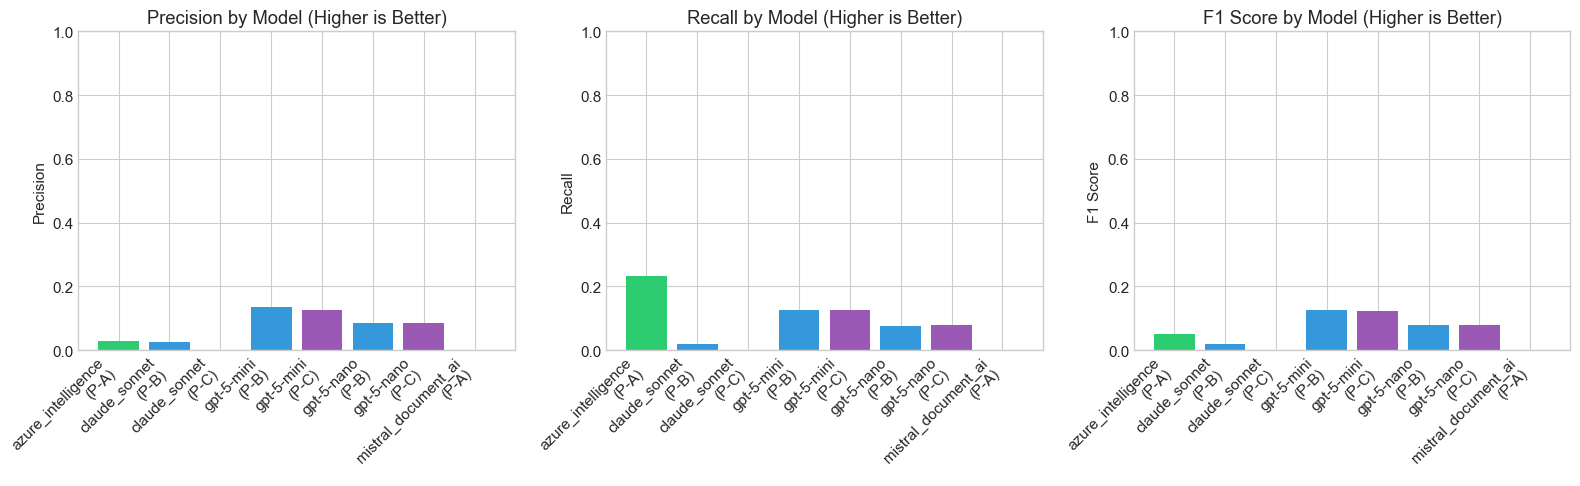

In [12]:
if len(all_metrics_df) > 0 and len(metrics_summary) > 0:
    # Bar charts: Precision, Recall, F1 by Model
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Color scheme for phases
    phase_colors = {
        'Phase P-A (OCR)': '#2ecc71',
        'Phase P-B (VLM)': '#3498db',
        'Phase P-C (VLM+)': '#9b59b6'
    }
    
    x_positions = range(len(metrics_summary))
    
    # Plot 1: Precision
    ax1 = axes[0]
    bars = ax1.bar(x_positions, metrics_summary['precision_mean'], 
                   color=[phase_colors.get(p, '#95a5a6') for p in metrics_summary['phase']])
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                          for _, row in metrics_summary.iterrows()], rotation=45, ha='right')
    ax1.set_ylabel('Precision')
    ax1.set_title('Precision by Model (Higher is Better)')
    ax1.set_ylim(0, 1.0)
    
    # Plot 2: Recall
    ax2 = axes[1]
    bars = ax2.bar(x_positions, metrics_summary['recall_mean'],
                   color=[phase_colors.get(p, '#95a5a6') for p in metrics_summary['phase']])
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                          for _, row in metrics_summary.iterrows()], rotation=45, ha='right')
    ax2.set_ylabel('Recall')
    ax2.set_title('Recall by Model (Higher is Better)')
    ax2.set_ylim(0, 1.0)
    
    # Plot 3: F1
    ax3 = axes[2]
    bars = ax3.bar(x_positions, metrics_summary['f1_mean'],
                   color=[phase_colors.get(p, '#95a5a6') for p in metrics_summary['phase']])
    ax3.set_xticks(x_positions)
    ax3.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                          for _, row in metrics_summary.iterrows()], rotation=45, ha='right')
    ax3.set_ylabel('F1 Score')
    ax3.set_title('F1 Score by Model (Higher is Better)')
    ax3.set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.savefig('../../../4_postprocessing/publaynet_precision_recall_f1.png', dpi=150, bbox_inches='tight')
    plt.show()

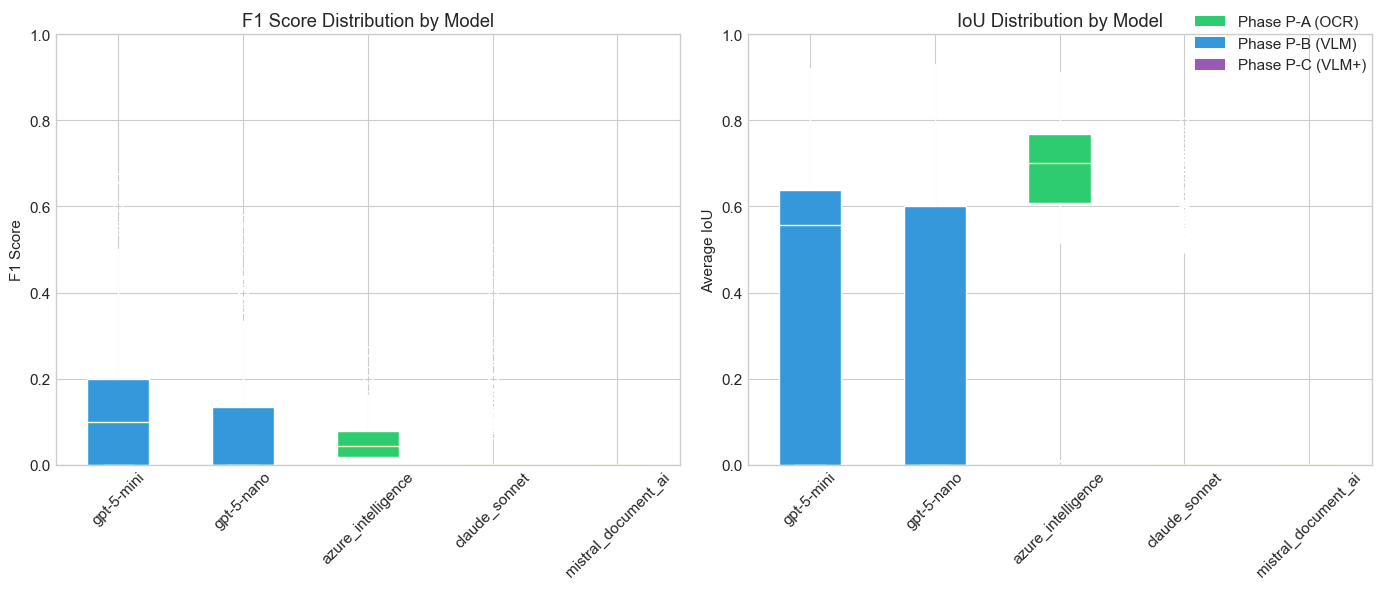

In [13]:
if len(all_metrics_df) > 0:
    # Box plots: F1 and IoU distribution by model
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Get models ordered by mean F1
    models_ordered = metrics_summary.sort_values('f1_mean', ascending=False)['model'].unique().tolist()
    
    # Box plot for F1
    ax1 = axes[0]
    box_data_f1 = [all_metrics_df[all_metrics_df['model'] == m]['f1'].values for m in models_ordered]
    bp1 = ax1.boxplot(box_data_f1, labels=models_ordered, patch_artist=True)
    
    # Color boxes by phase
    for i, model in enumerate(models_ordered):
        phase = metrics_summary[metrics_summary['model'] == model]['phase'].values[0]
        bp1['boxes'][i].set_facecolor(phase_colors.get(phase, '#95a5a6'))
    
    ax1.set_ylabel('F1 Score')
    ax1.set_title('F1 Score Distribution by Model')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, 1.0)
    
    # Box plot for IoU
    ax2 = axes[1]
    box_data_iou = [all_metrics_df[all_metrics_df['model'] == m]['avg_iou'].values for m in models_ordered]
    bp2 = ax2.boxplot(box_data_iou, labels=models_ordered, patch_artist=True)
    
    for i, model in enumerate(models_ordered):
        phase = metrics_summary[metrics_summary['model'] == model]['phase'].values[0]
        bp2['boxes'][i].set_facecolor(phase_colors.get(phase, '#95a5a6'))
    
    ax2.set_ylabel('Average IoU')
    ax2.set_title('IoU Distribution by Model')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 1.0)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=p) for p, c in phase_colors.items() 
                       if p in metrics_summary['phase'].values]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))
    
    plt.tight_layout()
    plt.savefig('../../../4_postprocessing/publaynet_f1_iou_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Category-Level Analysis

Analyze performance by document element type (text, title, list, table, figure).

In [14]:
def analyze_category_performance(df: pd.DataFrame, models: List[str], phase_name: str) -> pd.DataFrame:
    """Analyze detection performance by category."""
    results = []
    
    for model in models:
        pred_col = f"predicted_boxes_{model}"
        
        if pred_col not in df.columns:
            continue
        
        # Track metrics per category
        category_metrics = {cat: {'tp': 0, 'fp': 0, 'fn': 0} for cat in CATEGORY_NAMES.values()}
        
        for _, row in df.iterrows():
            gt_boxes = parse_boxes(row.get('ground_truth_boxes', ''))
            pred_boxes = parse_boxes(row.get(pred_col, ''))
            
            if len(gt_boxes) == 0:
                continue
            
            matched_pairs, unmatched_gt, unmatched_pred = match_boxes(pred_boxes, gt_boxes)
            
            # True positives (matched with correct category)
            for pred_idx, gt_idx, _ in matched_pairs:
                gt_cat = CATEGORY_NAMES.get(gt_boxes[gt_idx].get('category', 0), 'unknown')
                pred_cat = CATEGORY_NAMES.get(pred_boxes[pred_idx].get('category', 0), 'unknown')
                
                if gt_cat == pred_cat:
                    category_metrics[gt_cat]['tp'] += 1
                else:
                    category_metrics[gt_cat]['fn'] += 1
                    category_metrics[pred_cat]['fp'] += 1
            
            # False negatives (unmatched ground truth)
            for gt_idx in unmatched_gt:
                gt_cat = CATEGORY_NAMES.get(gt_boxes[gt_idx].get('category', 0), 'unknown')
                category_metrics[gt_cat]['fn'] += 1
            
            # False positives (unmatched predictions)
            for pred_idx in unmatched_pred:
                pred_cat = CATEGORY_NAMES.get(pred_boxes[pred_idx].get('category', 0), 'unknown')
                category_metrics[pred_cat]['fp'] += 1
        
        # Calculate metrics for each category
        for category, counts in category_metrics.items():
            tp, fp, fn = counts['tp'], counts['fp'], counts['fn']
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            
            results.append({
                'model': model,
                'phase': phase_name,
                'category': category,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'tp': tp,
                'fp': fp,
                'fn': fn
            })
    
    return pd.DataFrame(results)


# Analyze categories for each phase
all_category_metrics = []

for phase, df in phase_dfs.items():
    models = phase_models.get(phase, [])
    if models:
        print(f"Analyzing categories for {phase}...")
        cat_metrics = analyze_category_performance(df, models, phase_labels.get(phase, phase))
        all_category_metrics.append(cat_metrics)

if all_category_metrics:
    category_df = pd.concat(all_category_metrics, ignore_index=True)
    print(f"\nCategory-level metrics calculated for {len(category_df)} entries")
    
    # Display summary
    print("\nCategory Performance Summary (F1 scores):")
    print("=" * 80)
    pivot = category_df.pivot_table(index='category', columns=['model', 'phase'], values='f1')
    display(pivot.round(4))

Analyzing categories for P-A...
Analyzing categories for P-B...
Analyzing categories for P-C...

Category-level metrics calculated for 40 entries

Category Performance Summary (F1 scores):


model    azure_intelligence   claude_sonnet                       gpt-5-mini  \
phase       Phase P-A (OCR) Phase P-B (VLM) Phase P-C (VLM+) Phase P-B (VLM)   
category                                                                       
figure               0.0000          0.1330              0.0          0.3592   
list                 0.0000          0.0177              0.0          0.2542   
table                0.0000          0.0608              0.0          0.4331   
text                 0.0178          0.0028              0.0          0.0914   
title                0.0156          0.0042              0.0          0.0565   

model                          gpt-5-nano                  mistral_document_ai  
phase    Phase P-C (VLM+) Phase P-B (VLM) Phase P-C (VLM+)     Phase P-A (OCR)  
category                                                                        
figure             0.3016          0.2842           0.2421                 0.0  
list               0.1930          0.0504           0.0000                 0.0  
table              0.5154          0.3023           0.3525                 0.0  
text               0.0897          0.0442           0.0501                 0.0  
title              0.0551          0.0299           0.0237                 0.0

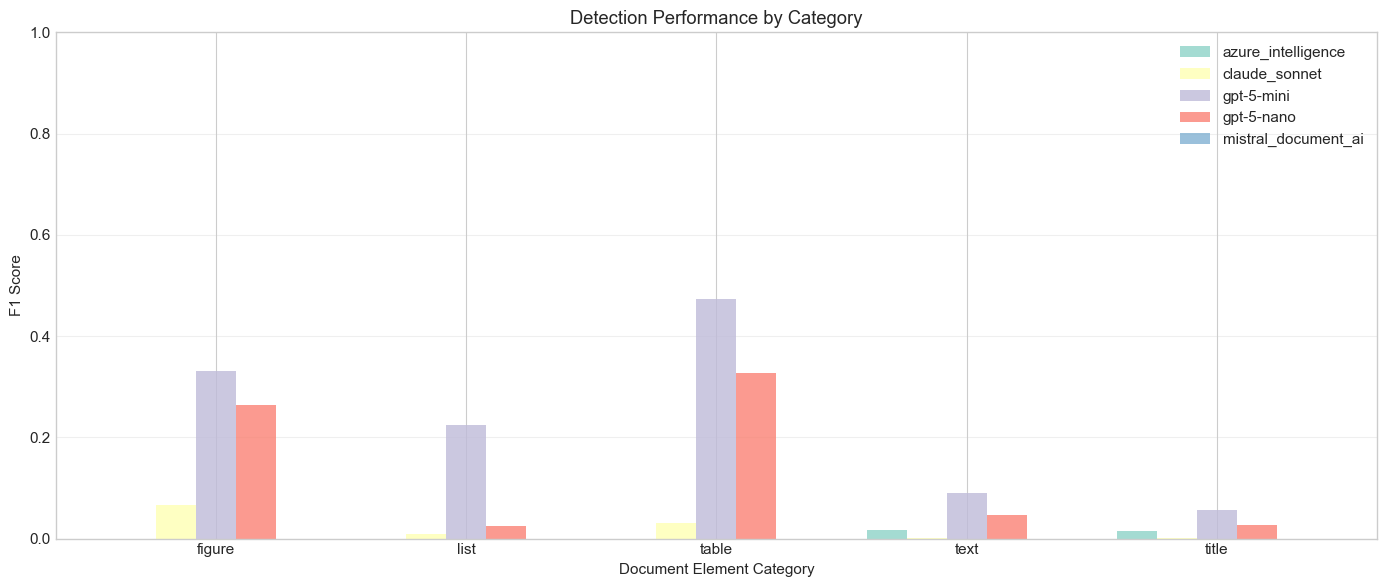

In [15]:
# Visualize category performance
if len(all_category_metrics) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Group by category and calculate mean F1
    cat_summary = category_df.groupby(['category', 'model'])['f1'].mean().reset_index()
    
    # Create grouped bar chart
    categories = sorted(cat_summary['category'].unique())
    models = sorted(cat_summary['model'].unique())
    
    x = np.arange(len(categories))
    width = 0.8 / len(models)
    
    for i, model in enumerate(models):
        model_data = cat_summary[cat_summary['model'] == model]
        f1_values = [model_data[model_data['category'] == cat]['f1'].values[0] 
                     if cat in model_data['category'].values else 0 
                     for cat in categories]
        ax.bar(x + i * width, f1_values, width, label=model, alpha=0.8)
    
    ax.set_xlabel('Document Element Category')
    ax.set_ylabel('F1 Score')
    ax.set_title('Detection Performance by Category')
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(categories)
    ax.legend(loc='best')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../../../4_postprocessing/publaynet_category_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Sample-Level Analysis

Identify easiest and hardest samples for models.

In [16]:
if len(all_metrics_df) > 0:
    # Pivot to compare same samples across models
    sample_pivot = all_metrics_df.pivot_table(
        index='sample_id', 
        columns='model', 
        values='f1',
        aggfunc='first'
    ).reset_index()
    
    # Calculate mean F1 across all models for each sample
    model_cols = [c for c in sample_pivot.columns if c != 'sample_id']
    sample_pivot['mean_f1'] = sample_pivot[model_cols].mean(axis=1)
    sample_pivot['std_f1'] = sample_pivot[model_cols].std(axis=1)
    
    # Best samples (highest mean F1)
    print("Top 10 EASIEST Samples (highest mean F1 across all models):")
    print("=" * 80)
    print(sample_pivot.nlargest(10, 'mean_f1')[['sample_id', 'mean_f1', 'std_f1']].to_string(index=False))
    
    print("\n")
    print("Top 10 HARDEST Samples (lowest mean F1 across all models):")
    print("=" * 80)
    print(sample_pivot.nsmallest(10, 'mean_f1')[['sample_id', 'mean_f1', 'std_f1']].to_string(index=False))

Top 10 EASIEST Samples (highest mean F1 across all models):
 sample_id  mean_f1   std_f1
      9236 0.221587 0.247745
     92880 0.202116 0.271964
    187731 0.201616 0.204032
    245380 0.198571 0.184763
     17541 0.190309 0.254334
    165166 0.180952 0.261688
     85392 0.177778 0.243432
    165162 0.169697 0.288755
    282563 0.163098 0.185887
    165157 0.163030 0.216411


Top 10 HARDEST Samples (lowest mean F1 across all models):
 sample_id  mean_f1  std_f1
      9233      0.0     0.0
      9235      0.0     0.0
      9237      0.0     0.0
     42714      0.0     0.0
     50245      0.0     0.0
     92842      0.0     0.0
    110118      0.0     0.0
    110164      0.0     0.0
    117883      0.0     0.0
    134116      0.0     0.0


In [17]:
# Analyze over-detection and under-detection patterns
if len(all_metrics_df) > 0:
    print("\nBox Count Analysis (Ground Truth vs Predictions):")
    print("=" * 80)
    
    for model in sorted(all_metrics_df['model'].unique()):
        model_data = all_metrics_df[all_metrics_df['model'] == model]
        
        avg_gt = model_data['gt_box_count'].mean()
        avg_pred = model_data['pred_box_count'].mean()
        over_detect_pct = (avg_pred / avg_gt - 1) * 100 if avg_gt > 0 else 0
        
        print(f"\n{model}:")
        print(f"  Avg GT boxes: {avg_gt:.1f}")
        print(f"  Avg predicted boxes: {avg_pred:.1f}")
        
        if over_detect_pct > 5:
            print(f"  ⚠️ Over-detection: {over_detect_pct:.1f}% more boxes than ground truth")
        elif over_detect_pct < -5:
            print(f"  ⚠️ Under-detection: {abs(over_detect_pct):.1f}% fewer boxes than ground truth")
        else:
            print(f"  ✓ Balanced detection: {over_detect_pct:+.1f}% vs ground truth")


Box Count Analysis (Ground Truth vs Predictions):

azure_intelligence:
  Avg GT boxes: 10.1
  Avg predicted boxes: 96.0
  ⚠️ Over-detection: 850.4% more boxes than ground truth

claude_sonnet:
  Avg GT boxes: 10.1
  Avg predicted boxes: 2.7
  ⚠️ Under-detection: 72.9% fewer boxes than ground truth

gpt-5-mini:
  Avg GT boxes: 10.1
  Avg predicted boxes: 8.2
  ⚠️ Under-detection: 18.4% fewer boxes than ground truth

gpt-5-nano:
  Avg GT boxes: 10.1
  Avg predicted boxes: 7.5
  ⚠️ Under-detection: 25.3% fewer boxes than ground truth

mistral_document_ai:
  Avg GT boxes: 10.1
  Avg predicted boxes: 0.0
  ⚠️ Under-detection: 100.0% fewer boxes than ground truth


## 12. Inference Time Analysis

Compare inference times and analyze speed vs accuracy tradeoffs.

Inference Time Summary:


,model,phase,inference_time_ms_mean,inference_time_ms_median,inference_time_ms_min,inference_time_ms_max,f1_mean
0,azure_intelligence,Phase P-A (OCR),3986.93,3409.95,2971.15,25294.81,0.05
1,claude_sonnet,Phase P-B (VLM),6243.39,6245.85,2438.71,12493.95,0.02
2,claude_sonnet,Phase P-C (VLM+),188.99,185.91,178.38,904.21,0.00
3,gpt-5-mini,Phase P-B (VLM),15760.31,14882.90,7845.69,136027.95,0.13
4,gpt-5-mini,Phase P-C (VLM+),14599.17,14254.42,8452.29,26531.15,0.12
5,gpt-5-nano,Phase P-B (VLM),17904.07,17349.81,7506.75,35767.06,0.08
6,gpt-5-nano,Phase P-C (VLM+),16658.60,16272.22,8306.53,29829.84,0.08
7,mistral_document_ai,Phase P-A (OCR),4269.28,3401.20,1402.29,60468.00,0.00


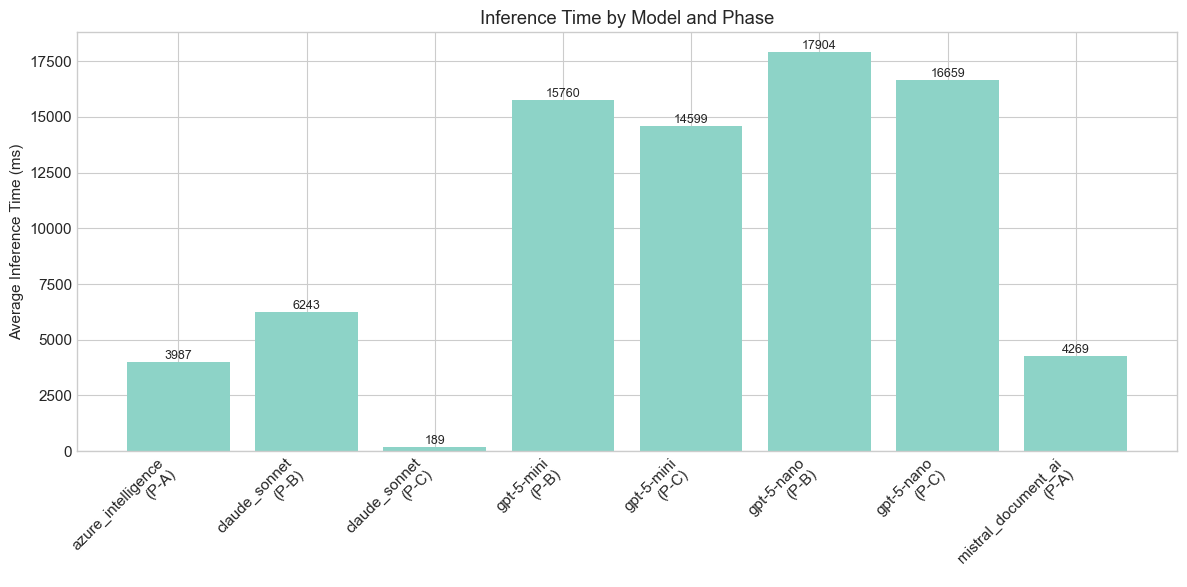

In [18]:
if len(all_metrics_df) > 0 and 'inference_time_ms' in all_metrics_df.columns:
    # Filter out missing times
    time_data = all_metrics_df.dropna(subset=['inference_time_ms'])
    
    if len(time_data) > 0:
        # Summary by model
        time_summary = time_data.groupby(['model', 'phase']).agg({
            'inference_time_ms': ['mean', 'median', 'min', 'max'],
            'f1': 'mean'
        }).round(2)
        
        time_summary.columns = ['_'.join(col) for col in time_summary.columns]
        time_summary = time_summary.reset_index()
        
        print("Inference Time Summary:")
        print("=" * 80)
        display(time_summary)
        
        # Visualize
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = range(len(time_summary))
        bars = ax.bar(x, time_summary['inference_time_ms_mean'])
        
        ax.set_xticks(x)
        ax.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                           for _, row in time_summary.iterrows()], rotation=45, ha='right')
        ax.set_ylabel('Average Inference Time (ms)')
        ax.set_title('Inference Time by Model and Phase')
        
        # Add value labels
        for bar, val in zip(bars, time_summary['inference_time_ms_mean']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig('../../../4_postprocessing/publaynet_inference_time.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("No inference time data available")

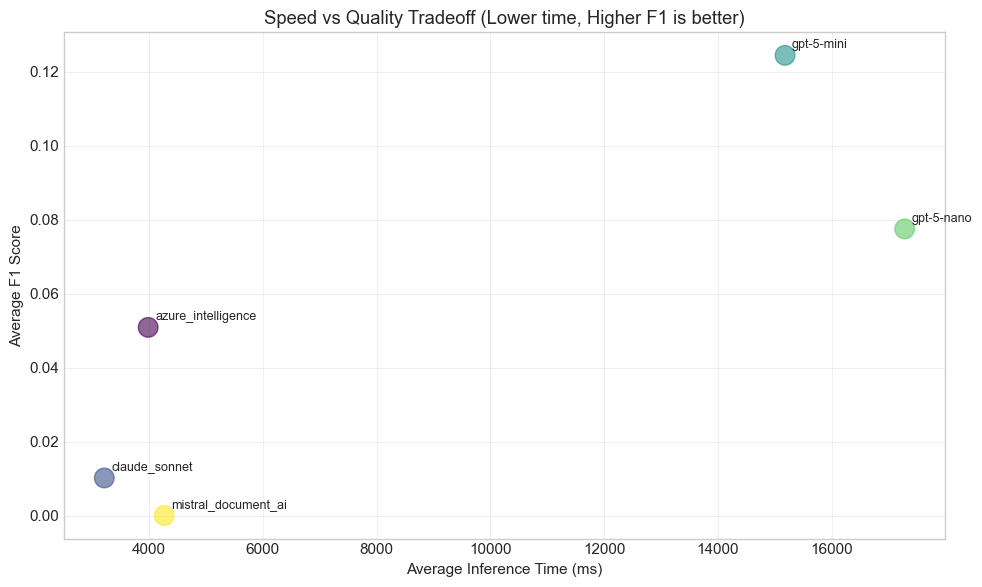

In [19]:
# Speed vs Quality scatterplot
if len(all_metrics_df) > 0 and 'inference_time_ms' in all_metrics_df.columns:
    time_data = all_metrics_df.dropna(subset=['inference_time_ms'])
    
    if len(time_data) > 0:
        # Calculate average F1 and inference time per model
        model_summary = time_data.groupby('model').agg({
            'f1': 'mean',
            'inference_time_ms': 'mean'
        }).reset_index()
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.scatter(model_summary['inference_time_ms'], model_summary['f1'], 
                   s=200, alpha=0.6, c=range(len(model_summary)), cmap='viridis')
        
        # Add model labels
        for _, row in model_summary.iterrows():
            ax.annotate(row['model'], 
                       (row['inference_time_ms'], row['f1']),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
        
        ax.set_xlabel('Average Inference Time (ms)')
        ax.set_ylabel('Average F1 Score')
        ax.set_title('Speed vs Quality Tradeoff (Lower time, Higher F1 is better)')
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('../../../4_postprocessing/publaynet_speed_quality_tradeoff.png', dpi=150, bbox_inches='tight')
        plt.show()

## 13. Export Results

Save analysis outputs for further use.

In [20]:
# Create output directory if needed
output_dir = Path('../../../4_postprocessing/publaynet_full')
output_dir.mkdir(parents=True, exist_ok=True)

if len(all_metrics_df) > 0:
    # Save detailed metrics
    all_metrics_df.to_csv(output_dir / 'detailed_metrics.csv', index=False)
    print(f"Saved detailed metrics to: {output_dir / 'detailed_metrics.csv'}")
    
    # Save model comparison
    if 'comparison_df' in dir() and len(comparison_df) > 0:
        comparison_df.to_csv(output_dir / 'model_comparison.csv', index=False)
        print(f"Saved model comparison to: {output_dir / 'model_comparison.csv'}")
    
    # Save category breakdown
    if 'category_df' in dir() and len(category_df) > 0:
        category_df.to_csv(output_dir / 'category_breakdown.csv', index=False)
        print(f"Saved category breakdown to: {output_dir / 'category_breakdown.csv'}")
    
    # Save sample-level analysis
    if 'sample_pivot' in dir():
        sample_pivot.to_csv(output_dir / 'sample_level_f1.csv', index=False)
        print(f"Saved sample-level F1 to: {output_dir / 'sample_level_f1.csv'}")
    
    print("\nAll exports complete!")
    print(f"Generated plots saved to: ../../../4_postprocessing/")
else:
    print("No data to export.")

Saved detailed metrics to: ../../../4_postprocessing/publaynet_full/detailed_metrics.csv
Saved model comparison to: ../../../4_postprocessing/publaynet_full/model_comparison.csv
Saved category breakdown to: ../../../4_postprocessing/publaynet_full/category_breakdown.csv
Saved sample-level F1 to: ../../../4_postprocessing/publaynet_full/sample_level_f1.csv

All exports complete!
Generated plots saved to: ../../../4_postprocessing/


## 14. Summary & Conclusions

### Key Findings:

1. **OCR vs VLM Performance**: 
   - Compare the F1, Precision, and Recall metrics between Phase P-A (OCR) and Phase P-B/P-C (VLM) models for document layout detection.
   - OCR models are specialized for layout detection, but VLMs offer more flexibility.

2. **Impact of Task-Aware Prompting**: 
   - Compare Phase P-B (generic prompts) vs Phase P-C (task-specific prompts) to determine if detailed instructions improve VLM performance.
   - Analyze whether prompting helps with specific categories (e.g., tables vs text).

3. **Best Performing Models**: 
   - Identify which models achieve the highest F1 scores for bounding box detection.
   - Consider speed vs accuracy tradeoffs.

4. **Category-Specific Performance**: 
   - Determine which document elements (text, title, table, figure, list) are easiest/hardest to detect.
   - Some categories may benefit more from VLM reasoning (e.g., distinguishing title from text).

5. **Detection Patterns**:
   - Analyze whether models tend to over-detect or under-detect boxes.
   - Identify common failure modes (missing small elements, merging adjacent boxes, etc.).

### Special Considerations for Document Layout Detection:
- IoU threshold of 0.5 is standard for object detection tasks
- Category accuracy is crucial - a detected box with wrong category is not useful
- Layout understanding requires spatial reasoning, not just text extraction
- Tables and figures are typically harder to detect than text blocks

### Next Steps:
- Test additional VLM models to expand comparison
- Experiment with different IoU thresholds
- Analyze failure cases in detail (visualize predictions)
- Compare with specialized layout detection models (LayoutLM, DETR-based)
- Evaluate on more diverse document types (papers, forms, magazines)